### Análisis Exploratorio de Datos (EDA)

In [60]:
#Importación de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [61]:
#importación de la dataset
intrusion = pd.read_csv(r"C:\Users\ntama\Documentos\Data Science\Gen Data\Prueba\prueba-gendata\data\cybersecurity_intrusion_data.csv")
intrusion.head()


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [62]:
#Inspección de las dimensiones de la dataset
print(f"Dimensiones de la dataset: {intrusion.shape}")

Dimensiones de la dataset: (9537, 11)


In [63]:
#Inspección de la info para observar presencia de valores nulos

print(intrusion.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB
None


Hay valores nulos en la columna "encryption_used"

In [64]:
#inspección de los valores únicos en las variables tipo object
for column in intrusion.select_dtypes(include='object').columns:
    print(f"Unique values for {column}: {intrusion[column].unique()}")
    print(f"Number of unique values: {len(intrusion[column].unique())}\n")


Unique values for session_id: ['SID_00001' 'SID_00002' 'SID_00003' ... 'SID_09535' 'SID_09536'
 'SID_09537']
Number of unique values: 9537

Unique values for protocol_type: ['TCP' 'UDP' 'ICMP']
Number of unique values: 3

Unique values for encryption_used: ['DES' 'AES' nan]
Number of unique values: 3

Unique values for browser_type: ['Edge' 'Firefox' 'Chrome' 'Unknown' 'Safari']
Number of unique values: 5



In [65]:
print(f"Hay un {(np.sum(intrusion['encryption_used'].isna())/len(intrusion['encryption_used']))*100}% de valores nulos en 'encryption_used' ")

Hay un 20.61444898815141% de valores nulos en 'encryption_used' 


Proporción de los valores de "encryption_used" para evaluación del posible tratamiento de valores nulos

In [66]:
print(intrusion['encryption_used'].value_counts(1))
print(intrusion.dtypes)


encryption_used
AES    0.621582
DES    0.378418
Name: proportion, dtype: float64
session_id              object
network_packet_size      int64
protocol_type           object
login_attempts           int64
session_duration       float64
encryption_used         object
ip_reputation_score    float64
failed_logins            int64
browser_type            object
unusual_time_access      int64
attack_detected          int64
dtype: object


El valor 'AES' se repite con una frecuencia de casi 2:1, se sustituirán los valores nulos por dicho valor

In [70]:
intrusion['encryption_used'] = intrusion['encryption_used'].fillna('AES')
for column in intrusion.select_dtypes(include='object').columns:
    print(f"Unique values for {column}: {intrusion[column].unique()}")
    print(f"Number of unique values: {len(intrusion[column].unique())}\n")

Unique values for session_id: ['SID_00001' 'SID_00002' 'SID_00003' ... 'SID_09535' 'SID_09536'
 'SID_09537']
Number of unique values: 9537

Unique values for protocol_type: ['TCP' 'UDP' 'ICMP']
Number of unique values: 3

Unique values for encryption_used: ['DES' 'AES']
Number of unique values: 2

Unique values for browser_type: ['Edge' 'Firefox' 'Chrome' 'Unknown' 'Safari']
Number of unique values: 5



Valores en la columna "session_id" son todos únicos </br>

In [ ]:
#Inspección de las métricas para las variable numéricas
print(intrusion.describe())

       network_packet_size  login_attempts  session_duration  \
count          9537.000000     9537.000000       9537.000000   
mean            500.430639        4.032086        792.745312   
std             198.379364        1.963012        786.560144   
min              64.000000        1.000000          0.500000   
25%             365.000000        3.000000        231.953006   
50%             499.000000        4.000000        556.277457   
75%             635.000000        5.000000       1105.380602   
max            1285.000000       13.000000       7190.392213   

       ip_reputation_score  failed_logins  unusual_time_access  \
count          9537.000000    9537.000000          9537.000000   
mean              0.331338       1.517773             0.149942   
std               0.177175       1.033988             0.357034   
min               0.002497       0.000000             0.000000   
25%               0.191946       1.000000             0.000000   
50%               0.314778 

Pair plot para todas las variables numéricas, agrupando por 'attack_detected'

c:\Users\ntama\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ntama\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ntama\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ntama\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

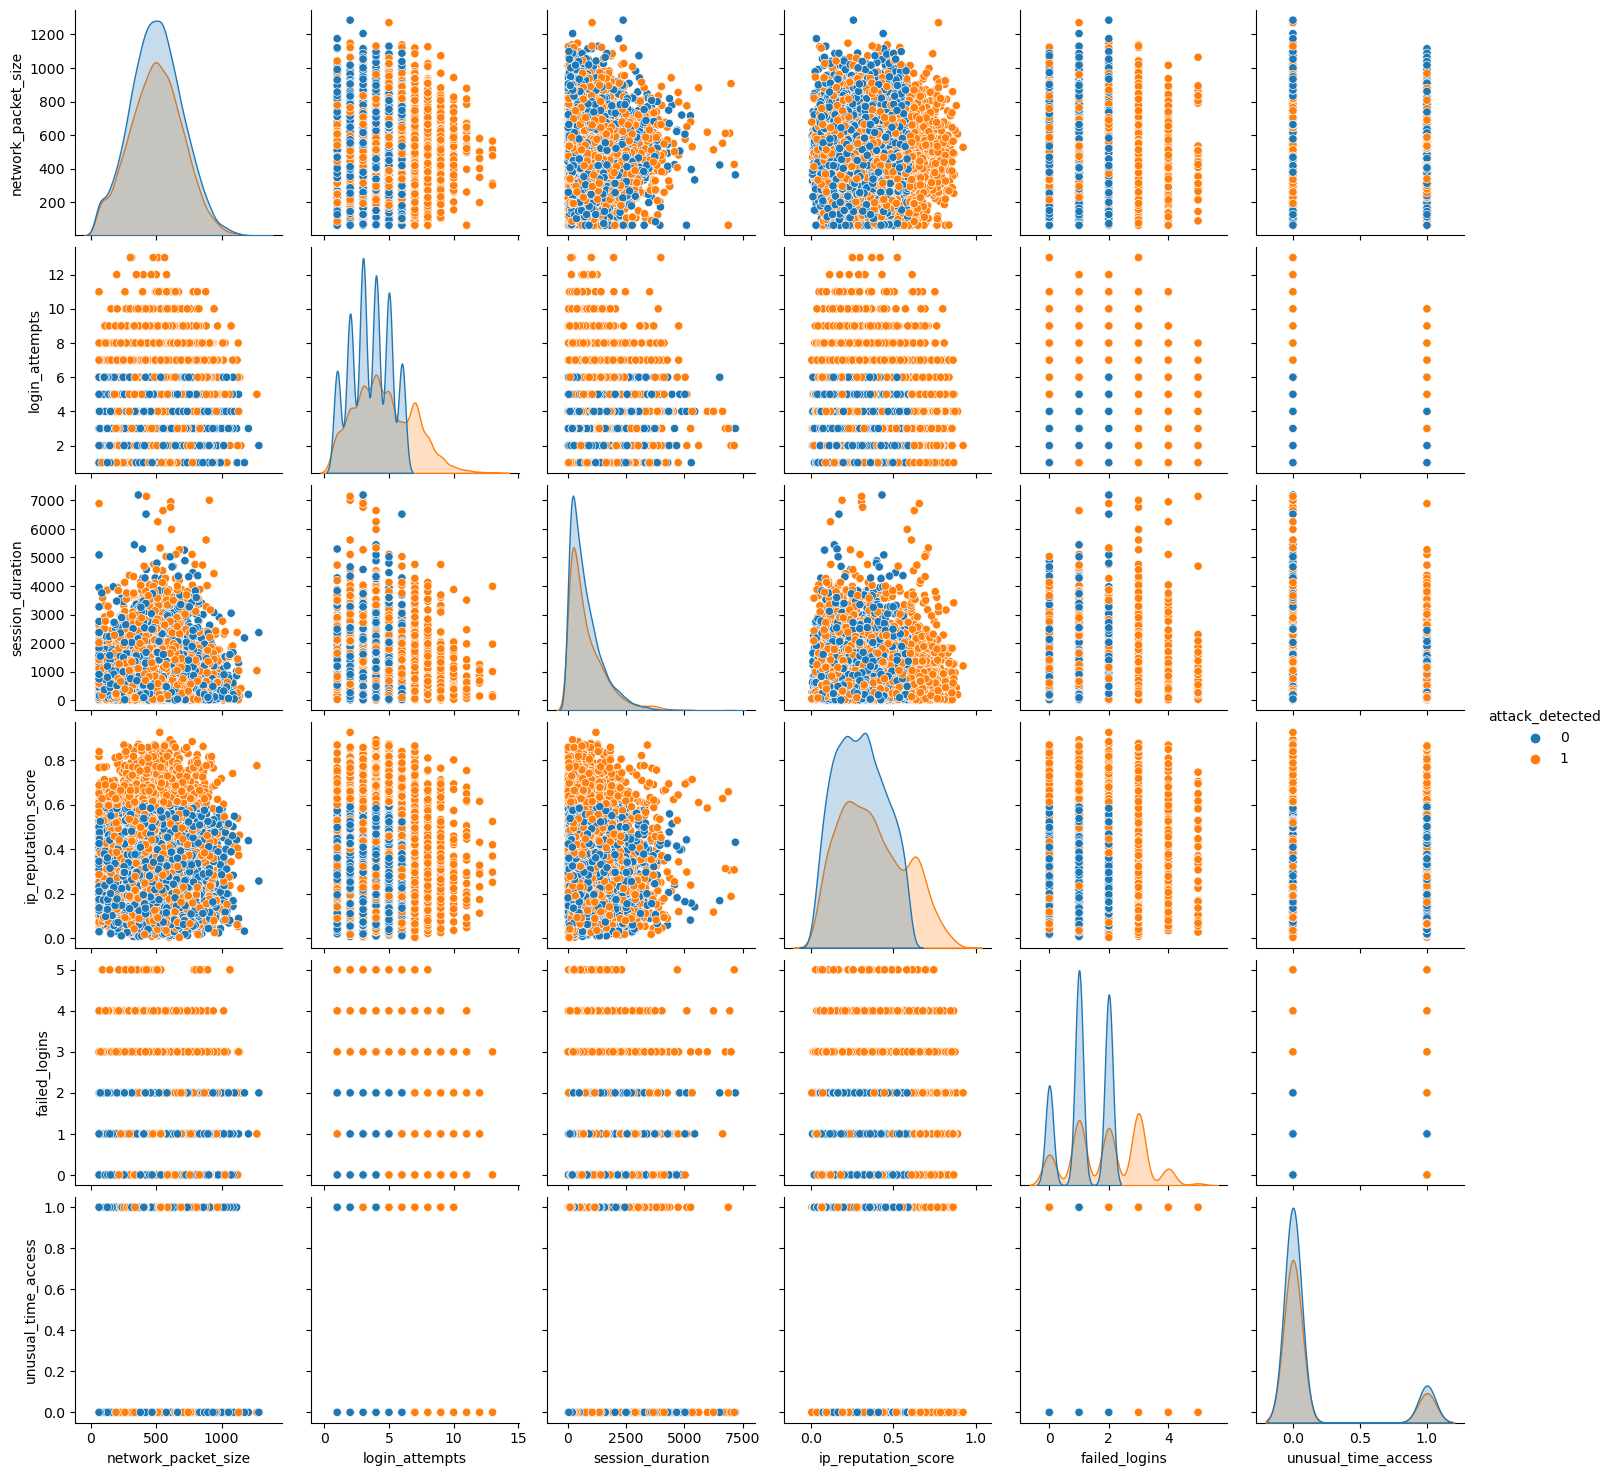

In [72]:
sns.pairplot(intrusion, hue='attack_detected')

No se observa multicolinearidad ni redundancia entre variables numéricas

Coeficientes de correlación para las variables numéricas

In [75]:
#Matriz de correlación
corr_matr = intrusion.corr(numeric_only=True)
corr_matr

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
network_packet_size,1.000000,-0.001890,0.021650,0.002320,-0.011676,-0.001255,-0.006798
login_attempts,-0.001890,1.000000,0.006392,-0.002618,-0.013507,0.007349,0.277320
session_duration,0.021650,0.006392,1.000000,-0.005077,0.019375,0.012930,0.041602
ip_reputation_score,0.002320,-0.002618,-0.005077,1.000000,0.015613,-0.003146,0.211540
failed_logins,-0.011676,-0.013507,0.019375,0.015613,1.000000,0.006131,0.363726
unusual_time_access,-0.001255,0.007349,0.012930,-0.003146,0.006131,1.000000,0.008652
attack_detected,-0.006798,0.277320,0.041602,0.211540,0.363726,0.008652,1.000000


Heatmap para las variables numéricas

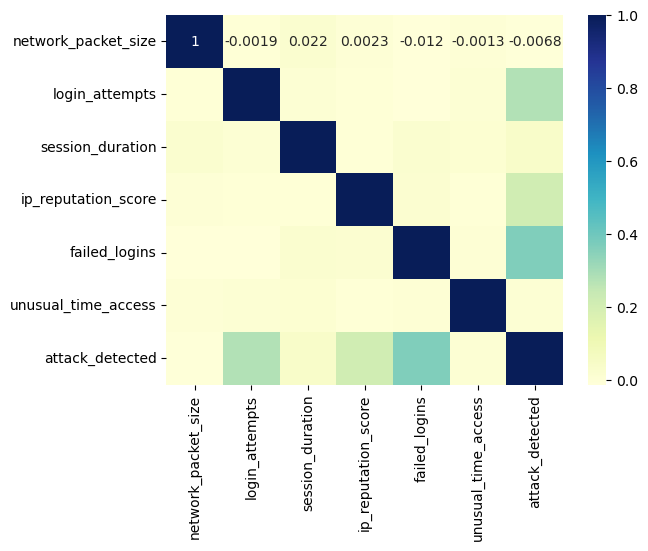

In [77]:
sns.heatmap(corr_matr, cmap="YlGnBu", annot=True)
plt.show()

Correlación entre variables categoricas

In [92]:
from itertools import combinations
from scipy.stats import chi2_contingency

#columnas categóricas en una lista
categ_var = list((intrusion.select_dtypes(include=object)).columns)

#loopeando para sacar las tablas de contingencia, p_values y chi2 de las variables categóricas de dos en dos
for var_a, var_b in combinations(categ_var, 2):
    tabla = pd.crosstab(intrusion[var_a], intrusion[var_b])
    chi2, p, dof, expected = chi2_contingency(tabla)
    print(f"{var_a} vs {var_b}: Chi² = {chi2:.2f}, p = {p:.4f}")

session_id vs protocol_type: Chi² = 19074.00, p = 0.4946
session_id vs encryption_used: Chi² = 9537.00, p = 0.4952
session_id vs browser_type: Chi² = 38148.00, p = 0.4933
protocol_type vs encryption_used: Chi² = 0.28, p = 0.8697
protocol_type vs browser_type: Chi² = 10.82, p = 0.2122
encryption_used vs browser_type: Chi² = 3.60, p = 0.4625


No hay relación entre las variables categóricas (p > 0.05), son por lo tanto independientes y no existe la multicolinearidad

Correlación entre variables categóricas y numéricas

In [ ]:
#Se descarta la columna "session_id"
intrusion = intrusion.drop(['session_id'], axis=1)

#columnas categóricas y numnéricas en listas

num_var = list((intrusion.select_dtypes(include='number')).columns)
categ_var = list((intrusion.select_dtypes(include=object)).columns)
print("Variables numéricas: ", num_var)
print("Variables categóricas: ", categ_var)

#loop para agrupar las medias de las variables numéricas por categoría
for i in range(len(categ_var)):
    for j in range(len(num_var)):
        current_mean = intrusion.groupby(categ_var[i])[num_var[j]].mean().sort_values()
        print(f"\nMedia de {num_var[j]} por {categ_var[i]}:")
        print(current_mean)

#El output es poco visual al haber muchas combinaciones, se deja la celda para reutilización de código si have falta

Variables numéricas:  ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected']
Variables categóricas:  ['protocol_type', 'encryption_used', 'browser_type']


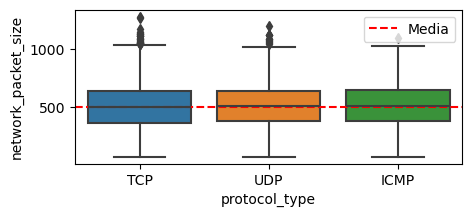

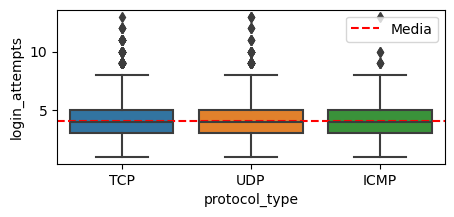

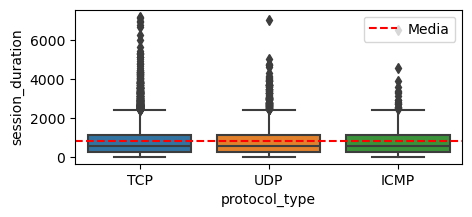

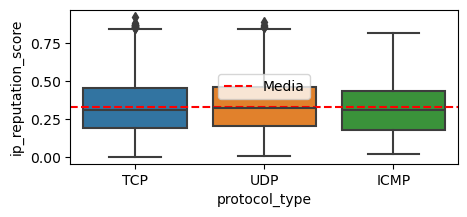

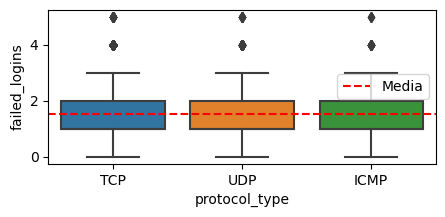

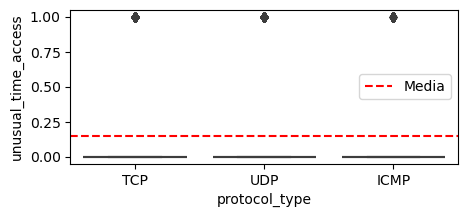

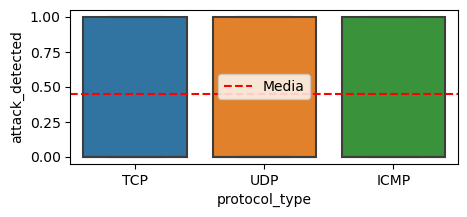

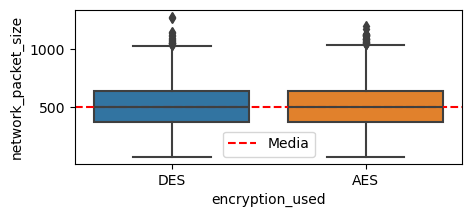

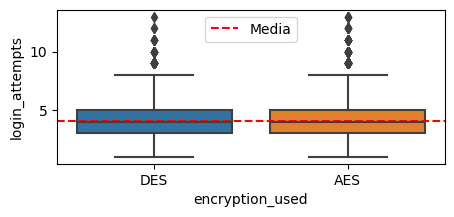

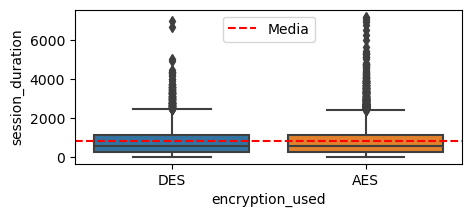

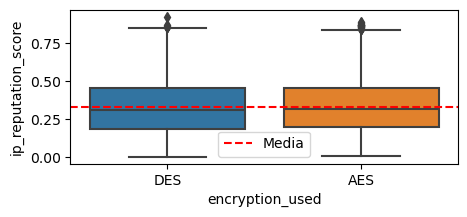

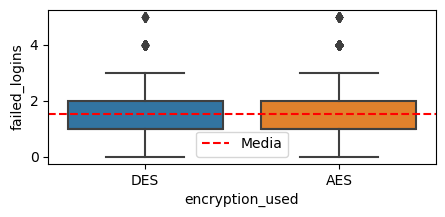

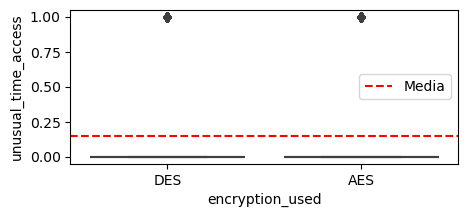

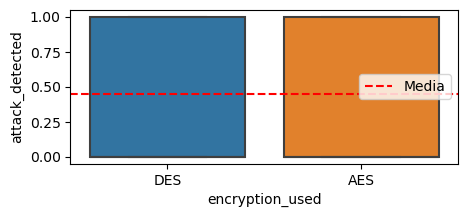

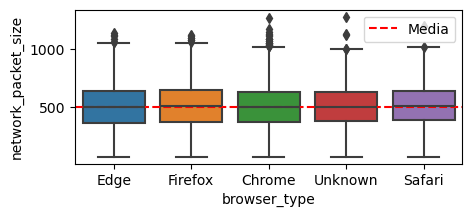

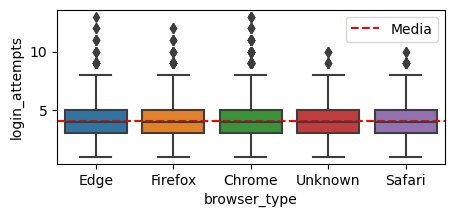

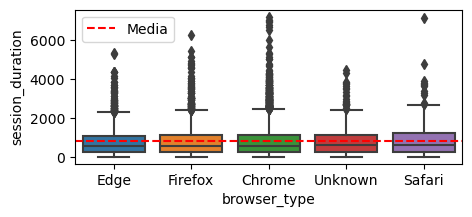

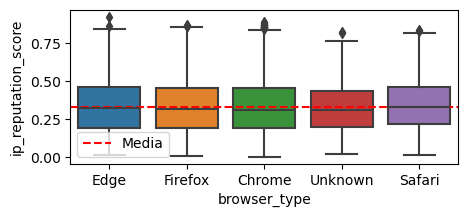

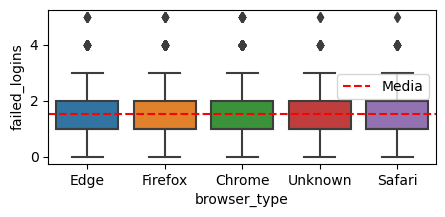

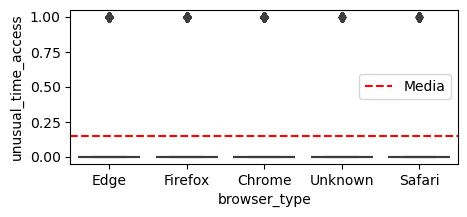

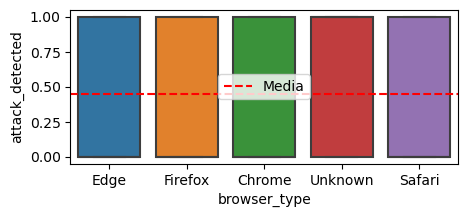

In [109]:
##columnas categóricas y numnéricas en listas
num_var = list((intrusion.select_dtypes(include='number')).columns)
categ_var = list((intrusion.select_dtypes(include=object)).columns)
print("Variables numéricas: ", num_var)
print("Variables categóricas: ", categ_var)

#loop para imprimir side-by-side boxplots
for i in range(len(categ_var)):
    for j in range(len(num_var)):
        plt.figure(figsize=(5,2))
        sns.boxplot(data=intrusion, x=categ_var[i], y=num_var[j])
        media = intrusion[num_var[j]].mean()
        plt.axhline(media, color='r', linestyle='--', label='Media')
        plt.legend()
        plt.show()

### Los boxplots de cada categoría son bastante similares (medianas cercanas, rangos similares), es posible que no haya una fuerte correlación entre variables numéricas y categóricas.

Generación de boxplots individuales para las variables numéricas para estudiar el tipo de transformación a realizar

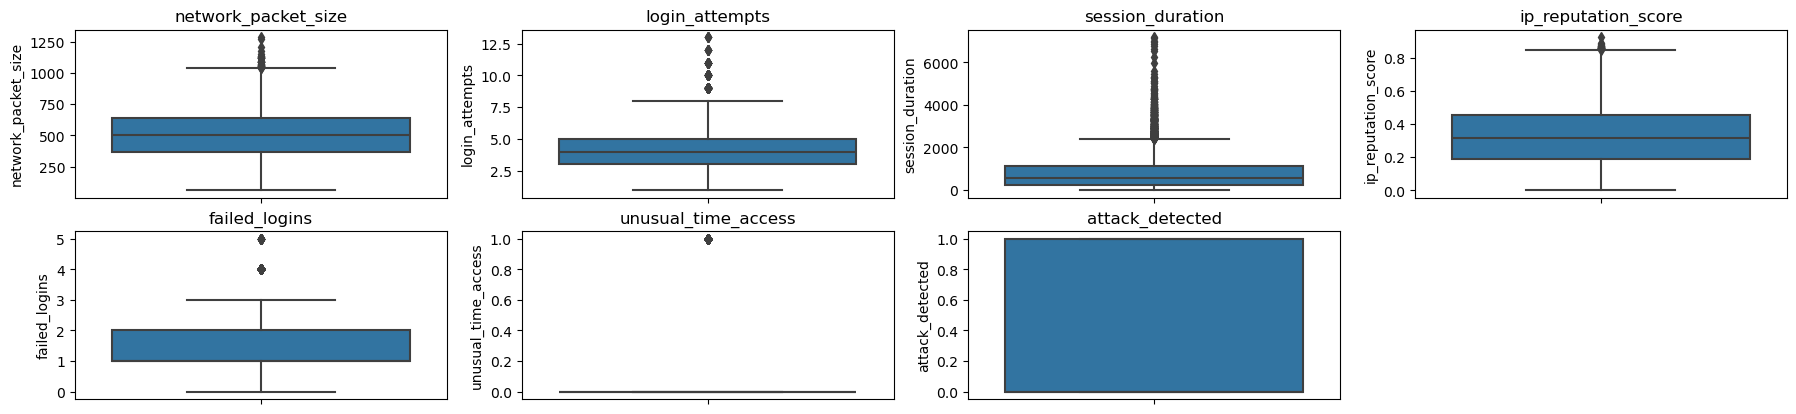

In [122]:
#boxplots para variables numéricas
for i in range(len(num_var)):
    plt.subplot(2, 4, i+1)
    sns.boxplot(data=intrusion, y=intrusion[num_var[i]])
    plt.title(f"{num_var[i]}")
    plt.subplots_adjust(right=2.8)


c:\Users\ntama\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ntama\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ntama\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ntama\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

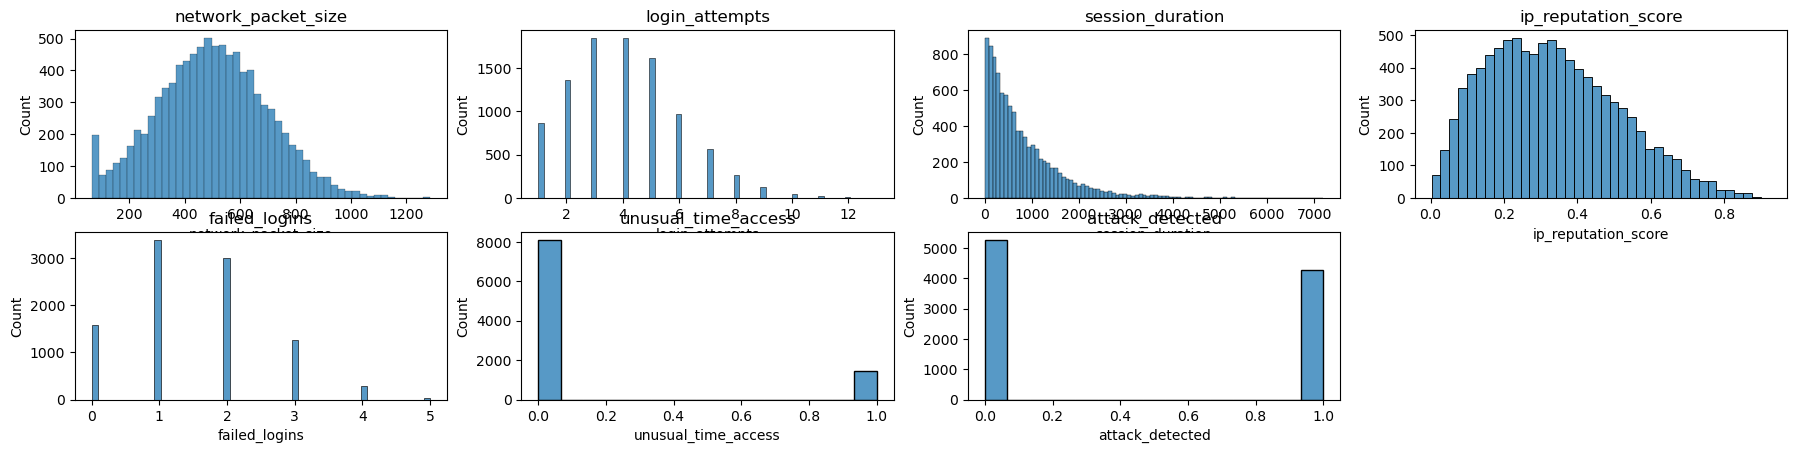

In [124]:
#histogramas para variables numéricas
for i in range(len(num_var)):
    plt.subplot(2, 4, i+1)
    sns.histplot(data=intrusion, x=intrusion[num_var[i]])
    plt.title(f"{num_var[i]}")
    plt.subplots_adjust(right=2.8)

### Conclusiones para la transformación de datos
Las variables tienen outliers y la mayoría están sesgadas hacia la derecha
#### Modelo de Regresión Logística (asume normalidad)
- *network_packet_size*: Transformación logarítmica
- *login_attempts*: Transformación logarítmica
- *session_duration*: Transformación logarítmica que soporta ceros
- *ip_reputation_score*: Transformación logarítmica que soporta ceros
- *failed_logins*: Transformación logarítmica que soporta ceros
- *unusual_time_access*: Sin transformar
- *attack_detected*: Sin transformar

#### Transformación de variables categóricas
Siendo pocas categorías --> One-hot Encoder a todas las variables

In [127]:
#exportación de la dataset con un primer filtro
intrusion_eda = intrusion.to_csv('intrusion_eda.csv', index=False)